# 06b - Tipologias de perfiles productivos por cultivo (Opcion B)

**Objetivo:** agrupar las 33 combinaciones `(region, cultivo)` por su **patron de produccion**
(forma estacional + escala + concentracion), de modo que **el cultivo si determine el cluster**
y no solo la geografia.

| Campo | Valor |
|-------|-------|
| Unidad de analisis | 33 perfiles `(region, cultivo)` |
| Features dominantes | vector de **estacionalidad mensual** (12 fracciones) |
| Features de escala | `log1p(produccion)`, n meses cosecha, concentracion, CV |
| Clima | reducido a **2 ejes PCA** (peso menor, no domina) |

**Por que esta version:** el perfil estacional distingue cultivos *dentro* del mismo distrito
(un cultivo de cosecha concentrada vs. uno permanente), algo que el clima -constante por
distrito- no puede hacer. Asi el clustering responde *"que cultivos comparten patron productivo"*.


## 1. Importaciones

In [1]:
# ====================================================================
# Importaciones
# ====================================================================
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")
PALETTE = sns.color_palette("tab10")
print("Librerias cargadas")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\USER\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\USER\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Librerias cargadas


## 2. Carga de datos

In [2]:
# ====================================================================
# Carga de dataset_integrado.csv y rutas de salida
# ====================================================================
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "Clustering":
    ROOT = ROOT.parent

RUTA_DATA = ROOT / "OUTPUTS" / "dataset_integrado.csv"
RUTA_OUT = ROOT / "OUTPUTS"
RUTA_FIG = RUTA_OUT / "figures"
RUTA_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_DATA)

CLIMA_VARS = [
    "temp_promedio", "temp_maxima", "temp_minima", "precipitacion",
    "humedad_relativa", "radiacion_solar", "velocidad_viento",
    "presion_atmosferica", "humedad_suelo", "temp_superficie",
    "punto_rocio", "humedad_especifica",
]
CLIMA_CORE = [
    "temp_promedio", "precipitacion", "humedad_relativa",
    "radiacion_solar", "humedad_suelo",
]

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print("Regiones :", sorted(df["region"].unique()))
print("Distritos:", df["distrito"].nunique(), "| Pisos:", sorted(df["piso_ecologico"].unique()))
print("Cultivos :", df["cultivo"].nunique())


Dimensiones: 2,376 filas x 20 columnas
Regiones : ['Ica', 'Junin', 'La Libertad', 'Piura', 'Puno', 'San Martin']
Distritos: 12 | Pisos: ['altiplano_lacustre', 'bosque_seco', 'costa', 'puna_alta', 'selva_alta', 'selva_alto_mayo', 'selva_baja', 'selva_huallaga', 'sierra', 'valle_chira']
Cultivos : 19


In [3]:
# ====================================================================
# Funciones auxiliares de seleccion de K (reutilizables)
# ====================================================================
def eval_kmeans_range(X, k_range, random_state=42):
    """Barrido de K: inercia, Silhouette, Calinski-Harabasz, Davies-Bouldin."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        lbl = km.fit_predict(X)
        rows.append({
            "k": k, "inertia": km.inertia_,
            "silhouette": silhouette_score(X, lbl),
            "calinski": calinski_harabasz_score(X, lbl),
            "davies_bouldin": davies_bouldin_score(X, lbl),
        })
    return pd.DataFrame(rows)


def elegir_k(df_km):
    """K optimo: coincidencia Silhouette/Davies-Bouldin, o ranking promedio."""
    best_sil = int(df_km.loc[df_km["silhouette"].idxmax(), "k"])
    best_db = int(df_km.loc[df_km["davies_bouldin"].idxmin(), "k"])
    if best_sil == best_db:
        return best_sil, "coincidencia Silhouette y Davies-Bouldin"
    rank_sil = df_km.set_index("k")["silhouette"].rank(ascending=False)
    rank_db = df_km.set_index("k")["davies_bouldin"].rank(ascending=True)
    k_opt = int((rank_sil + rank_db).idxmin())
    return k_opt, f"ranking promedio (Sil={best_sil}, DB={best_db})"


def plot_k_selection(df_km, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(df_km["k"], df_km["inertia"], "o-"); axes[0].set_title("Inercia (codo)")
    axes[1].plot(df_km["k"], df_km["silhouette"], "o-", color="green"); axes[1].set_title("Silhouette (mayor=mejor)")
    axes[2].plot(df_km["k"], df_km["davies_bouldin"], "o-", color="red"); axes[2].set_title("Davies-Bouldin (menor=mejor)")
    for ax in axes:
        ax.set_xlabel("K")
    plt.suptitle(titulo, fontweight="bold"); plt.tight_layout(); plt.show()


## 3. Construccion de perfiles productivos

Para cada `(region, cultivo)`:
- **Estacionalidad:** produccion sumada por mes calendario (2020-2025) y normalizada por el
  total -> 12 fracciones que describen *la forma* del calendario productivo (independiente de escala).
- **Escala:** `log1p(produccion_total)` (evita que la cana de Viru, 28 M t, sea un outlier brutal).
- **Concentracion:** fraccion del mes pico y nº de meses con cosecha.
- **Variabilidad:** coeficiente de variacion mensual.
- **Clima:** 2 componentes principales del clima del distrito (peso reducido frente a 12+ features productivas).


In [4]:
# ====================================================================
# Perfiles productivos: estacionalidad + escala + concentracion + clima(2 PCA)
# ====================================================================
MESES = list(range(1, 13))

# --- Estacionalidad: matriz cultivo x mes (suma 2020-2025) ---
piv = (df.groupby(["region", "cultivo", "numero_mes"])["produccion_ton"].sum()
       .unstack("numero_mes").reindex(columns=MESES).fillna(0.0))
totales = piv.sum(axis=1)
estacional = piv.div(totales.replace(0, np.nan), axis=0).fillna(0.0)
estacional.columns = [f"frac_m{m:02d}" for m in MESES]

# --- Features de escala / concentracion / variabilidad ---
perf = pd.DataFrame(index=piv.index)
perf["log_produccion"] = np.log1p(totales)
perf["frac_mes_pico"] = estacional.max(axis=1)              # concentracion (1 = todo en 1 mes)
perf["n_meses_cosecha"] = (piv > 0).sum(axis=1)             # amplitud del calendario
mean_mes = piv.mean(axis=1)
perf["cv_mensual"] = piv.std(axis=1) / mean_mes.replace(0, np.nan)
perf["cv_mensual"] = perf["cv_mensual"].fillna(0.0)

# --- Clima del distrito reducido a 2 ejes PCA ---
clima_distrito = df.groupby(["region", "cultivo"])[CLIMA_CORE].mean()
clima_z = StandardScaler().fit_transform(clima_distrito)
clima_pca = PCA(n_components=2, random_state=42).fit_transform(clima_z)
perf["clima_pc1"] = clima_pca[:, 0]
perf["clima_pc2"] = clima_pca[:, 1]

# --- Ensamble final ---
df_perfil = estacional.join(perf).reset_index()
df_perfil["etiqueta"] = df_perfil["region"] + " | " + df_perfil["cultivo"]

FEATURES = list(estacional.columns) + [
    "log_produccion", "frac_mes_pico", "n_meses_cosecha", "cv_mensual",
    "clima_pc1", "clima_pc2",
]
X = StandardScaler().fit_transform(df_perfil[FEATURES])
print(f"Perfiles: {len(df_perfil)} | features: {len(FEATURES)} "
      f"({len(estacional.columns)} estacionales + {len(FEATURES)-len(estacional.columns)} escala/clima)")
df_perfil[["region", "cultivo", "log_produccion", "frac_mes_pico", "n_meses_cosecha"]].head(10)


Perfiles: 33 | features: 18 (12 estacionales + 6 escala/clima)


,region,cultivo,log_produccion,frac_mes_pico,n_meses_cosecha
0,Ica,alfalfa,13.538021,0.184142,12
1,Ica,esparrago,13.774477,0.155804,12
2,Ica,maiz_amarillo_duro,13.736534,0.188716,12
3,Ica,mandarina,13.916536,0.244800,11
4,Ica,palta,13.377985,0.256485,10
5,Ica,papa,13.581468,0.453481,12
6,Ica,tomate,13.461700,0.302883,12
7,Ica,uva,14.783285,0.374601,12
8,Junin,alfalfa,13.628351,0.094725,12
9,Junin,avena_forrajera,13.328103,0.267863,12


## 4. Seleccion de K y clustering

Barrido K=2..8 sobre los perfiles productivos estandarizados.


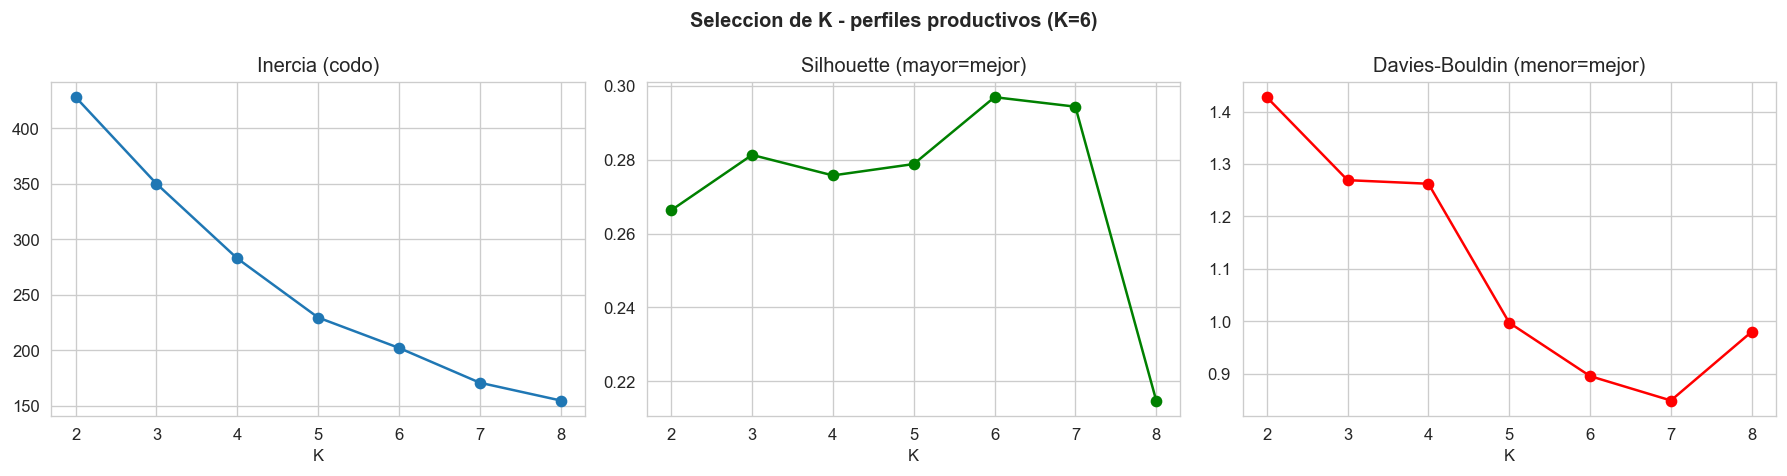

K optimo: 6 (ranking promedio (Sil=6, DB=7))
KMeans K=6 | Silhouette=0.297 | Davies-Bouldin=0.896


In [5]:
# ====================================================================
# KMeans sobre perfiles productivos + seleccion de K
# ====================================================================
km_df = eval_kmeans_range(X, k_range=range(2, 9))
K_PERFIL, motivo = elegir_k(km_df)
plot_k_selection(km_df, f"Seleccion de K - perfiles productivos (K={K_PERFIL})")
print(f"K optimo: {K_PERFIL} ({motivo})")

km = KMeans(n_clusters=K_PERFIL, random_state=42, n_init=10)
df_perfil["cluster"] = km.fit_predict(X)
sil = silhouette_score(X, df_perfil["cluster"])
db = davies_bouldin_score(X, df_perfil["cluster"])
print(f"KMeans K={K_PERFIL} | Silhouette={sil:.3f} | Davies-Bouldin={db:.3f}")


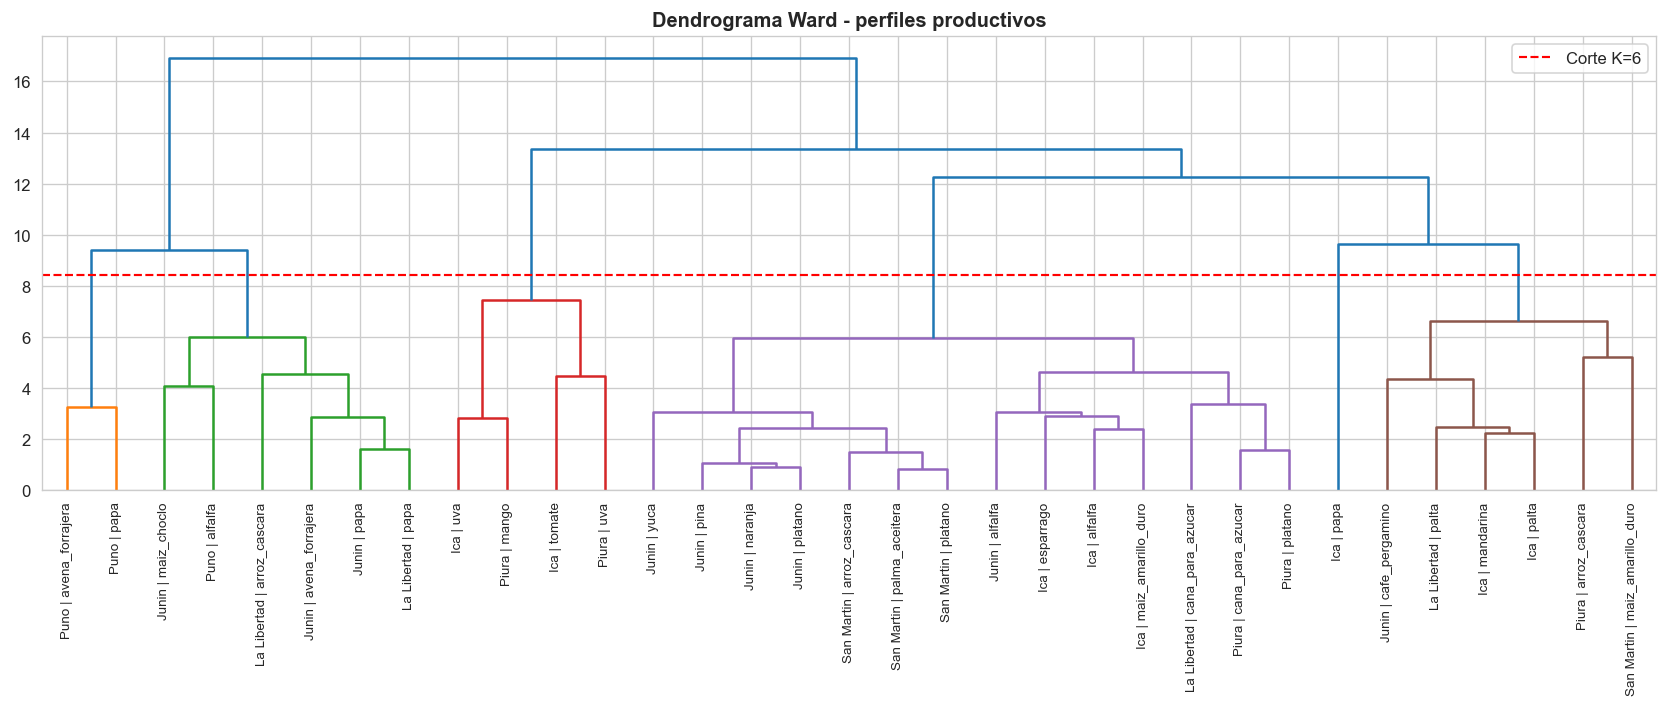

In [6]:
# ====================================================================
# Dendrograma Ward (validacion)
# ====================================================================
Z = linkage(X, method="ward")
# Altura de corte que produce K_PERFIL clusters (linea roja discontinua).
thr = (Z[-K_PERFIL, 2] + Z[-(K_PERFIL - 1), 2]) / 2
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=df_perfil["etiqueta"].tolist(), leaf_rotation=90, leaf_font_size=8,
           color_threshold=thr, ax=ax)
ax.axhline(thr, color="red", ls="--", lw=1.3, label=f"Corte K={K_PERFIL}")
ax.legend(loc="upper right")
ax.set_title("Dendrograma Ward - perfiles productivos", fontweight="bold")
plt.tight_layout()
plt.savefig(RUTA_FIG / "06b_dendrograma_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Interpretacion: patrones de calendario productivo

El heatmap de estacionalidad por cluster es la pieza central: muestra **la forma del calendario
de cada grupo** (permanente y plano vs. cosecha concentrada en ciertos meses). Aqui el cultivo
si manda.


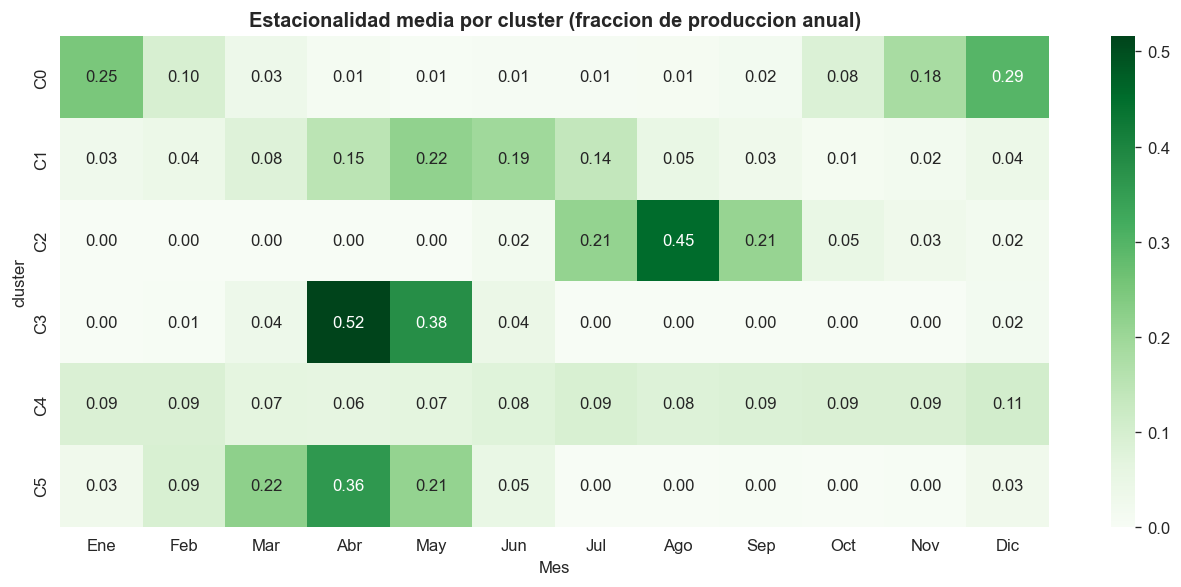


Cluster 0 (4 cultivos) | mes pico medio: Dic
  log_prod=14.2 | concentracion=0.36 | meses_cosecha=12.0
  Cultivos: Ica-tomate, Ica-uva, Piura-mango, Piura-uva

Cluster 1 (10 cultivos) | mes pico medio: May
  log_prod=14.0 | concentracion=0.26 | meses_cosecha=11.2
  Cultivos: Ica-maiz_amarillo_duro, Ica-mandarina, Ica-palta, Junin-avena_forrajera, Junin-cafe_pergamino, Junin-papa, La Libertad-arroz_cascara, La Libertad-palta, La Libertad-papa, Piura-arroz_cascara

Cluster 2 (1 cultivos) | mes pico medio: Ago
  log_prod=13.6 | concentracion=0.45 | meses_cosecha=12.0
  Cultivos: Ica-papa

Cluster 3 (2 cultivos) | mes pico medio: Abr
  log_prod=15.9 | concentracion=0.52 | meses_cosecha=7.0
  Cultivos: Puno-avena_forrajera, Puno-papa

Cluster 4 (14 cultivos) | mes pico medio: Dic
  log_prod=14.5 | concentracion=0.13 | meses_cosecha=12.0
  Cultivos: Ica-alfalfa, Ica-esparrago, Junin-alfalfa, Junin-naranja, Junin-pina, Junin-platano, Junin-yuca, La Libertad-cana_para_azucar, Piura-cana_para_

In [7]:
# ====================================================================
# Heatmap de estacionalidad media por cluster (12 meses)
# ====================================================================
nombres_mes = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
cent_est = df_perfil.groupby("cluster")[list(estacional.columns)].mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cent_est, annot=True, fmt=".2f", cmap="Greens",
            yticklabels=[f"C{i}" for i in cent_est.index],
            xticklabels=nombres_mes, ax=ax)
ax.set_title("Estacionalidad media por cluster (fraccion de produccion anual)", fontweight="bold")
ax.set_xlabel("Mes")
plt.tight_layout()
plt.savefig(RUTA_FIG / "06b_heatmap_estacionalidad.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen interpretable por cluster
for c in sorted(df_perfil["cluster"].unique()):
    sub = df_perfil[df_perfil["cluster"] == c]
    mes_pico = nombres_mes[int(cent_est.loc[c].values.argmax())]
    print(f"\nCluster {c} ({len(sub)} cultivos) | mes pico medio: {mes_pico}")
    print(f"  log_prod={sub['log_produccion'].mean():.1f} | "
          f"concentracion={sub['frac_mes_pico'].mean():.2f} | "
          f"meses_cosecha={sub['n_meses_cosecha'].mean():.1f}")
    print(f"  Cultivos: {', '.join(sub['region'] + '-' + sub['cultivo'])}")


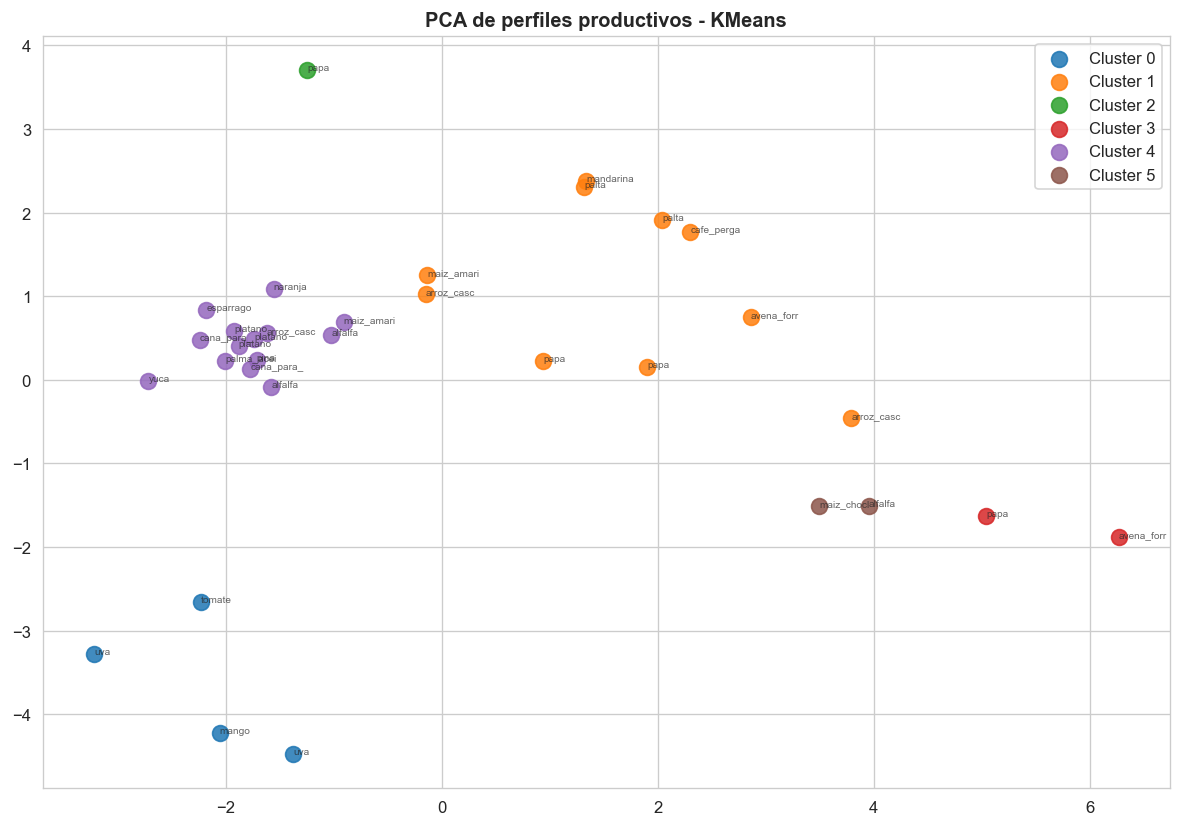

In [8]:
# ====================================================================
# PCA 2D de los perfiles, coloreado por cluster
# ====================================================================
xy = PCA(n_components=2, random_state=42).fit_transform(X)
fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(df_perfil["cluster"].unique()):
    msk = df_perfil["cluster"] == c
    ax.scatter(xy[msk, 0], xy[msk, 1], s=90, alpha=0.85, label=f"Cluster {c}")
for i, row in df_perfil.iterrows():
    ax.annotate(row["cultivo"][:10], (xy[i, 0], xy[i, 1]), fontsize=6, alpha=0.7)
ax.set_title("PCA de perfiles productivos - KMeans", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(RUTA_FIG / "06b_pca_perfiles.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Exportacion y conclusiones

In [9]:
# ====================================================================
# Exportacion de resultados
# ====================================================================
export = df_perfil[["region", "cultivo", "cluster", "log_produccion",
                    "frac_mes_pico", "n_meses_cosecha", "cv_mensual"]].copy()
export.to_csv(RUTA_OUT / "06b_perfiles_productivos_clusters.csv",
              index=False, encoding="utf-8-sig")

print("=" * 60)
print("CONCLUSIONES - Opcion B (perfiles productivos)")
print("=" * 60)
print(f"K = {K_PERFIL} clusters | Silhouette = {sil:.3f}")
print("- El cluster lo determina el PATRON PRODUCTIVO (estacionalidad + escala),")
print("  no la geografia: cultivos de distintas regiones con igual calendario se agrupan.")
print("- El clima entra solo como 2 ejes PCA secundarios (no domina).")
print("- log1p() neutraliza el outlier de la cana de Viru.")
print("- Exportado: 06b_perfiles_productivos_clusters.csv")


CONCLUSIONES - Opcion B (perfiles productivos)
K = 6 clusters | Silhouette = 0.297
- El cluster lo determina el PATRON PRODUCTIVO (estacionalidad + escala),
  no la geografia: cultivos de distintas regiones con igual calendario se agrupan.
- El clima entra solo como 2 ejes PCA secundarios (no domina).
- log1p() neutraliza el outlier de la cana de Viru.
- Exportado: 06b_perfiles_productivos_clusters.csv
